<a href="https://colab.research.google.com/github/4-the-spirit/Skin-Cancer-Detection-Neural-Network/blob/main/Deep_Learning_Seminar_Skin_Cancer_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Author: Tamir Globus**

**ID: 213381031**

# **Skin Cancer Detection Project**

# **Introduction**

## **The Challenge**

**Problem Description & Purpose:**
Skin cancer is the most common form of cancer worldwide, with melanoma being its deadliest subtype. Although melanoma accounts for only a small fraction of skin cancer cases, it is responsible for nearly 75% of skin cancer–related deaths. In 2020 alone, the American Cancer Society estimated more than 100,000 new melanoma cases and nearly 7,000 related deaths in the United States. As with most cancers, early and accurate detection is critical, as timely intervention can significantly improve treatment outcomes.

Traditionally, dermatologists rely on close visual inspection of all skin lesions, focusing on “outlier” moles—often referred to as the “ugly duckling” sign—that deviate from the patient’s other lesions. While this approach has proven valuable, it remains subjective and prone to human error. Advances in artificial intelligence (AI) and computer vision offer the potential to support dermatologists by automating lesion analysis and highlighting suspicious cases. However, many existing AI methods overlook the patient-level context that clinicians naturally incorporate when comparing lesions.

From a machine learning perspective, this is formulated as a binary classification problem. The dataset contains dermoscopic images of skin lesions labeled as either benign or malignant, along with patient-level metadata such as sex, age, and anatomical site. The goal is to train a model that can automatically classify each lesion image into its correct category (benign = 0, malignant = 1).

**Solution Impact:**
The proposed solution has the potential to significantly improve the early detection and diagnosis of melanoma. By integrating dermoscopic images with patient-level metadata, the model is designed to more closely mirror the way dermatologists assess lesions in practice, thereby improving classification accuracy and clinical relevance. Earlier and more reliable detection can increase the chances of successful treatment while reducing unnecessary biopsies, ultimately lowering healthcare costs and minimizing patient discomfort. Beyond clinical support, such a system could be transformative in terms of accessibility: with only an internet connection, individuals in remote areas, underserved regions, or developing countries could benefit from AI-assisted screening, even in the absence of readily available dermatologists. Similarly, in developed countries where long wait times to see a specialist can delay diagnosis, an automated tool could provide earlier risk assessment, ensuring timely intervention. Ultimately, this solution demonstrates how AI-driven healthcare can extend life-saving diagnostic capabilities to millions of people worldwide, bridging the gap between medical expertise and patient needs.

<div style="display: flex; gap: 20px; align-items: flex-start;">
  <!-- First image -->
  <div style="text-align:center;">
    <img src="https://s.yimg.com/ny/api/res/1.2/OhIJJV2AtD4tteZoozpBAw--/YXBwaWQ9aGlnaGxhbmRlcjt3PTk2MDtoPTU2MTtjZj13ZWJw/https://media.zenfs.com/en/globenewswire.com/2b76a1c54c75e7988e50b7b01188d5ae" width="400">
    <p>Source: <a href="https://finance.yahoo.com/news/global-melanoma-therapeutics-market-size-070000275.html?guccounter=1&guce_referrer=aHR0cHM6Ly93d3cuZ29vZ2xlLmNvbS8&guce_referrer_sig=AQAAAKGtg65y-SiIlI9i2VF4ZCVswcBexuQdi_DBokDkpFzQWCGPKceKrLUofdstPpB7QbxyAO7vTtwwUCsgnBUuJ3R9vqz2BbM5gAzmJRltby1EjLuB6l9Iw8JgJ4sO-d80hBDhw2tVRkrv_yX-_uDEsA68VD9t_vA6AE9q9Jh7RrCL"><b>Yahoo Finance</b></a></p>
  </div>

  <!-- Second image -->
  <div style="text-align:center;">
    <img src="https://cdn.statcdn.com/Infographic/images/normal/32207.jpeg" width="400">
    <p>Source: <a href="https://www.statista.com/chart/32207/new-cases-and-deaths-from-melanoma-of-the-skin/"><b>Statista</b></a></p>
  </div>
</div>


## **Data Collection**

The dataset for this project comes from the **SIIM-ISIC Melanoma Classification Challenge** on Kaggle (https://www.kaggle.com/competitions/siim-isic-melanoma-classification/overview), organized by the **Society for Imaging Informatics in Medicine (SIIM)** and the **International Skin Imaging Collaboration (ISIC)**. It represents the largest publicly available collection of quality-controlled dermoscopic images of skin lesions, created to support research in automated melanoma detection.

The dataset includes 33,126 training images and 10,982 test images in both JPEG and DICOM formats, each paired with structured patient-level metadata. The training metadata contains the following fields:

* **image_name** - unique identifier linking to the corresponding image file
* **patient_id** - unique identifier for each patient (allowing grouping of multiple lesions per patient)
* **sex** - patient sex (blank if unknown)
* **age_approx** - approximate patient age at the time of imaging
* **anatom_site_general_challenge** - anatomical site of the lesion (e.g., torso, lower extremity)
* **diagnosis** - detailed diagnostic label (present only in the training set)
* **benign_malignant** - categorical indicator of lesion type (benign or malignant)
* **target** - binarized training label (0 = benign, 1 = malignant)

The test metadata contains **only the first five features** (`image_name`, `patient_id`, `sex`, `age_approx`, `anatom_site_general_challenge`) and does not include `diagnosis`, `benign_malignant`, or `target`.

Ground-truth labels are established through rigorous validation: **malignant cases** are confirmed by histopathology, while **benign cases** are verified by expert consensus or clinical follow-up.

This combination of dermoscopic images and clinical metadata makes the dataset especially well-suited for developing multi-modal deep learning models that integrate both visual and contextual patient information to improve melanoma detection.

# **Data Preprocessing**

Before performing data understanding and analysis in the EDA process, we must first prepare the data for processing, while also ensuring that no information from the test set is accidentally leaked into the training set. We begin by loading the tabular data into Pandas DataFrames and defining the paths for the training and test sets:

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy
import pandas

unknown = "unknown"

project_path = "/content/drive/MyDrive/SkinCancerDetectionProject"
data_path = os.path.join(project_path, "data")

train_images_path = os.path.join(data_path, "train")
test_images_path = os.path.join(data_path, "test")

# Avoid loading the image names lists to the RAM.!!!
# train_image_names_iterator = os.scandir(train_images_path)
# test_image_names_iterator = os.scandir(test_images_path)

train_df = pandas.read_csv(os.path.join(project_path, "train.csv"))
test_df = pandas.read_csv(os.path.join(project_path, "test.csv"))

**Split into Train/Validation/Test**

The test set is stored in a separate directory. We will reserve 20% of the training data as a validation set, which will be used for model evaluation and hyperparameter tuning:

In [3]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["target"],
    random_state=42
)

In [4]:
def get_id_to_path_map(paths, image_names):
    image_names_set = set(image_names)
    id_to_path = {}
    for f in os.listdir(paths):
        stem, ext = os.path.splitext(f)
        key = stem.lower().strip()
        if key in image_names_set:
            id_to_path[key] = os.path.join(paths, f)
    return id_to_path

for df in [train_df, val_df, test_df]:
    df["image_name_reduced"] = df["image_name"].str.replace(r"\.[^.]+$", "", regex=True).str.strip().str.lower()

id_to_train_path = get_id_to_path_map(train_images_path, train_df["image_name_reduced"])
id_to_val_path = get_id_to_path_map(train_images_path, val_df["image_name_reduced"])
id_to_test_path = get_id_to_path_map(test_images_path, test_df["image_name_reduced"])

train_df["image_path"] = train_df["image_name_reduced"].map(id_to_train_path)
val_df["image_path"] = val_df["image_name_reduced"].map(id_to_val_path)
test_df["image_path"] = test_df["image_name_reduced"].map(id_to_test_path)

for df in [train_df, val_df, test_df]:
  df.drop("image_name_reduced", axis=1, inplace=True)

In [5]:
for name, df in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
    missing = df["image_path"].isna().sum()
    total = len(df)
    print(f"{name}: {missing} missing image paths out of {total} rows")

train_df: 0 missing image paths out of 26500 rows
val_df: 0 missing image paths out of 6626 rows
test_df: 0 missing image paths out of 10982 rows


**Handle Missing Values**

An important step in preprocessing is identifying and addressing missing values in the dataset. Certain features in the training set contain incomplete data, which must be handled carefully to avoid bias and ensure the model can learn effectively. The following columns were found to have missing values:

In [6]:
base_message = "{0} Set - Missing Values:\n"
breaker = "\n" + ("-" * 40)

missing_counts = train_df.isna().sum()
print(base_message.format("Training"), missing_counts[missing_counts > 0], breaker)

missing_counts = val_df.isna().sum()
print(base_message.format("Validation"), missing_counts[missing_counts > 0], breaker)

missing_counts = test_df.isna().sum()
print(base_message.format("Test"), missing_counts[missing_counts > 0], breaker)

Training Set - Missing Values:
 sex                               55
age_approx                        58
anatom_site_general_challenge    424
dtype: int64 
----------------------------------------
Validation Set - Missing Values:
 sex                               10
age_approx                        10
anatom_site_general_challenge    103
dtype: int64 
----------------------------------------
Test Set - Missing Values:
 anatom_site_general_challenge    351
dtype: int64 
----------------------------------------


We address missing values using different strategies tailored to each feature. For the `sex` column, we replace missing values with an `"unknown"` category, ensuring that all patients remain in the dataset **without introducing bias or distorting the class distribution** by arbitrarily assigning `"male"` or `"female"`.

For the `age_approx` column, we impute missing entries with the **median age**, a robust measure that preserves the overall distribution while minimizing the influence of outliers.

Finally, for the `anatom_site_general_challenge` column, we apply a **conditional sampling strategy:** each missing entry is filled based on the observed probability distribution of anatomical sites given the patient’s age. This approach maintains consistency with clinical patterns observed in the dataset and avoids discarding valuable samples.

In [7]:
def sample_conditional_variable(df, conditioned_variable, conditioning_variable):
  prob_table = df.groupby(conditioning_variable)[conditioned_variable].value_counts(normalize=True)

  def sample(row):
      if pandas.isna(row[conditioned_variable]):
          val = row[conditioning_variable]
          if val in prob_table.index.levels[0]:
              choices = prob_table[val].index.tolist()
              probs = prob_table[val].values
              return numpy.random.choice(choices, p=probs)
          else:
              return unknown
      else:
          return row[conditioned_variable]
  return sample

def fill_anatom_site_value():
  train_age_median = train_df["age_approx"].median()
  train_df["age_approx"] = train_df["age_approx"].fillna(train_age_median)
  train_df["age_bin"] = pandas.cut(train_df["age_approx"], bins=list(range(0, 101, 10)), include_lowest=True)

  sample_row_func = sample_conditional_variable(train_df, "anatom_site_general_challenge", "age_bin")

  def fill_value(row):
    return sample_row_func(row)

  return fill_value

def handle_missing_values(df, age_median):
    df = df.copy()
    df["age_approx"] = df["age_approx"].fillna(age_median)
    df["age_bin"] = pandas.cut(df["age_approx"], bins=list(range(0, 101, 10)), include_lowest=True)
    df["sex"] = df["sex"].fillna(unknown)
    df["anatom_site_general_challenge"] = df.apply(fill_anatom_site_value(), axis=1)
    return df

In [8]:
train_age_median = train_df["age_approx"].median()

train_df = handle_missing_values(train_df, train_age_median)
val_df = handle_missing_values(val_df, train_age_median)
test_df = handle_missing_values(test_df, train_age_median)

# Save the cleaned unencoded training set for EDA
unencoded_train_df = train_df.copy()

/tmp/ipython-input-3910285357.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_table = df.groupby(conditioning_variable)[conditioned_variable].value_counts(normalize=True)
/tmp/ipython-input-3910285357.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_table = df.groupby(conditioning_variable)[conditioned_variable].value_counts(normalize=True)
/tmp/ipython-input-3910285357.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silenc

Because the validation and test sets represent **unseen data**, we should not impute their missing values using information from within those sets. Instead, any missing values in the validation and test sets <u>must be filled using statistics (e.g., mean, median, mode) that are computed from the training set, or using features combination of the sample that its missing value is filled.</u> In our case, we computed the conditional distribution of `anatom_site_general_challenge | age_approx` based on the training set. We then used this distribution to impute missing values of the `anatom_site_general_challenge` feature in the validation and test sets, conditioning on the `age_approx` value of each sample.

**Encode Labels**

We use **one-hot encoding** to represent discrete variables that should not carry an ordinal relationship or are non-numeric. In general, we prefer one-hot encoding over label encoding, since label encoding introduces artificial ordinal relationships that are not meaningful. Here, we apply one-hot encoding to the two categorical features, `anatom_site_general_challenge` and `sex`, which we include in the training process:

In [9]:
def encode_labels(df, columns):
  return pandas.get_dummies(df, columns=columns, dummy_na=False)

In [10]:
train_df = encode_labels(train_df, columns=["sex", "anatom_site_general_challenge"])
val_df = encode_labels(val_df, columns=["sex", "anatom_site_general_challenge"])
test_df = encode_labels(test_df, columns=["sex", "anatom_site_general_challenge"])

In [11]:
train_df.head()

,image_name,patient_id,age_approx,diagnosis,benign_malignant,target,image_path,age_bin,sex_female,sex_male,sex_unknown,anatom_site_general_challenge_head/neck,anatom_site_general_challenge_lower extremity,anatom_site_general_challenge_oral/genital,anatom_site_general_challenge_palms/soles,anatom_site_general_challenge_torso,anatom_site_general_challenge_upper extremity
4410,ISIC_1429439,IP_8140841,75.0,unknown,benign,0,/content/drive/MyDrive/SkinCancerDetectionProj...,"(70.0, 80.0]",False,True,False,False,False,False,False,False,True
1861,ISIC_0658963,IP_1870306,75.0,unknown,benign,0,/content/drive/MyDrive/SkinCancerDetectionProj...,"(70.0, 80.0]",False,True,False,False,False,False,False,True,False
24570,ISIC_7459410,IP_3722746,50.0,nevus,benign,0,/content/drive/MyDrive/SkinCancerDetectionProj...,"(40.0, 50.0]",False,True,False,False,False,False,False,True,False
23914,ISIC_7261174,IP_8041141,15.0,melanoma,malignant,1,/content/drive/MyDrive/SkinCancerDetectionProj...,"(10.0, 20.0]",True,False,False,True,False,False,False,False,False
3387,ISIC_1124744,IP_2610032,40.0,nevus,benign,0,/content/drive/MyDrive/SkinCancerDetectionProj...,"(30.0, 40.0]",False,True,False,False,False,False,False,False,True


Notice that we do not apply one-hot encoding to the `diagnosis` feature, since it is **not included in the training process**. We exclude it because **the test set lacks this feature**, meaning that a model trained with `diagnosis` would not be able to evaluate test samples consistently. The preferred way to handle the complete absence of a feature is by defining an auxiliary task, but we avoid this approach due to its added complexity. For now, we remove `diagnosis` from the training and validation sets:

In [12]:
train_df = train_df.drop("diagnosis", axis=1)
val_df = val_df.drop("diagnosis", axis=1)

**Balance the Classes**

To address class imbalance in the target variable, we use Scikit-learn's built-in `compute_class_weight` function to calculate weights that ensure each class contributes proportionally to the model's learning process:

In [13]:
from sklearn.utils.class_weight import compute_class_weight

def get_balancing_weights(df, column):
  vals = df[column].values
  weights = compute_class_weight(
      class_weight="balanced",
      classes=numpy.unique(vals),
      y=vals
  )
  return dict(enumerate(weights))

class_to_weight_mapping = get_balancing_weights(train_df, "target")

**Resize and Normalize Images**

We define two utility functions to handle **image preprocessing** and **data augmentation**, which are essential when training convolutional neural networks, especially with transfer learning:

In [14]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers

IMAGE_HEIGHT = 240
IMAGE_WIDTH = 240

def preprocessing_block(inputs, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
  x = layers.Resizing(image_size[0], image_size[1])(inputs)
  x = layers.Lambda(preprocess_input)(x)
  return x

**Augment Images**

In [15]:
def augmentation_block(inputs, seed=None):
  augmentation_model = tf.keras.Sequential([
      layers.RandomFlip("horizontal", seed=seed),
      layers.RandomRotation(0.4, fill_mode="reflect", seed=seed),
      layers.RandomZoom(0.15, fill_mode="reflect", seed=seed),
      layers.RandomTranslation(0.05, 0.05, fill_mode="reflect", seed=seed),
      layers.RandomContrast(0.1, seed=seed)
  ], name="data_augmentation")
  return augmentation_model(inputs)

# **EDA (Exploratory Data Analysis)**

This chapter presents an exploratory analysis of the training dataset. Several methods are employed to uncover and visualize relationships among the features, including conditional probability between variable pairs, dimensionality reduction techniques, clustering algorithms, and more. Since each sample in the training set consists of two distinct feature types - a vector and an image, we first apply different analytical approaches to each type separately, allowing for more tailored and meaningful insights.

## **Visualizing Distributions**

Visualizing the data is a crucial step in understanding it. Each sample in the training set consists of an **image** and a corresponding **metadata vector**. Therefore, it is natural to first visualize the images and the tabular data separately, and then proceed with more advanced visualizations.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

**Visualizing Feature Distributions**

We begin by examining the target variable, which indicates whether a lesion is benign (`0`) or malignant (`1`), to confirm whether the dataset is balanced or imbalanced:

/tmp/ipython-input-291727889.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=unencoded_train_df, x="target", palette=["royalblue", "red"])


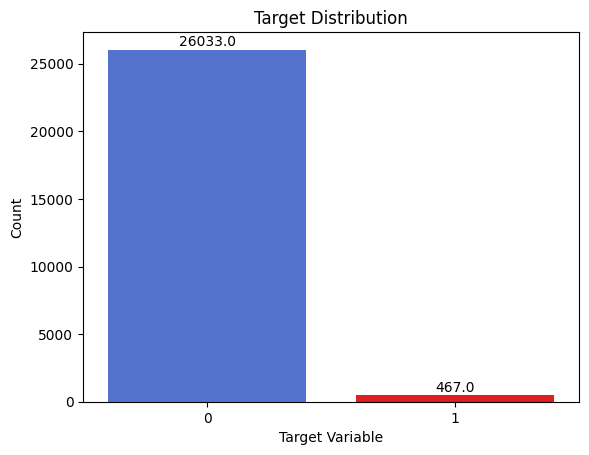

In [17]:
ax = sns.countplot(data=unencoded_train_df, x="target", palette=["royalblue", "red"])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height + 80), ha='center', va='bottom')

plt.title("Target Distribution")
plt.xlabel("Target Variable")
plt.ylabel("Count")
plt.show()

As we see, the dataset exhibits a significant class imbalance - negative (`0`) samples are **much more common** than positive (`1`) samples. Such imbalance can lead to poor model performance, as the model may simply learn to predict the majority class. <u>We assume this imbalance reflects sampling rather than the true distribution of the target variable.</u> Therefore, **in preprocessing we applied class weighting**, overweighting the positive samples and underweighting the negative ones, which was a crucial step to ensure balanced learning.

Next, we look at the distribution of **patient ages** and compare it across target classes. Melanoma is often associated with older patients, so it is important to see whether malignant cases are more concentrated in certain age groups:

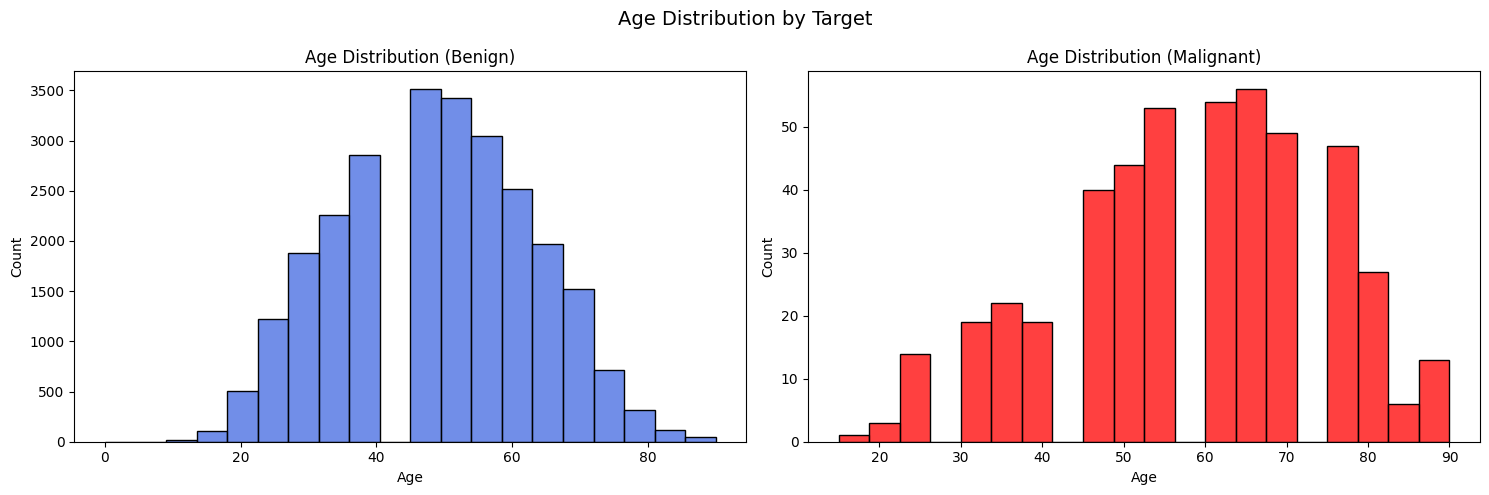

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=unencoded_train_df[unencoded_train_df["target"] == 0],
    x="age_approx",
    bins=20,
    color="royalblue",
    ax=axes[0]
)
axes[0].set_title("Age Distribution (Benign)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.histplot(
    data=unencoded_train_df[unencoded_train_df["target"] == 1],
    x="age_approx",
    bins=20,
    color="red",
    ax=axes[1]
)
axes[1].set_title("Age Distribution (Malignant)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

plt.suptitle("Age Distribution by Target", fontsize=14)
plt.tight_layout()
plt.show()

It seems that the ages of malignant cases are concentrated mostly in the 50-70 range, whereas benign cases are more concentrated around 40-60. This suggests a **potential correlation between** `age` **and the target variable**. Since benign cases make up the majority of the dataset, the overall age distribution is naturally dominated by the age profile of the benign samples - as we can see here:

Text(0.5, 0, 'Age')

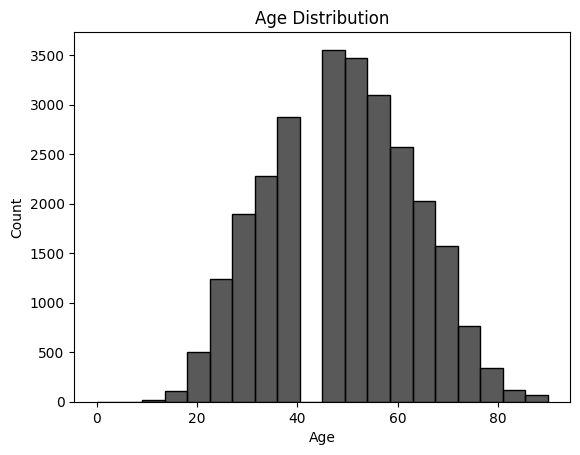

In [19]:
sns.histplot(data=unencoded_train_df, x="age_approx", bins=20, color="#222222")
plt.title("Age Distribution")
plt.xlabel("Age")

We then explore the distribution of `sex` in the dataset to identify any imbalance between male and female patients. This also allows us to observe whether the likelihood of malignancy differs between the two groups, which can highlight possible biological or dataset-specific patterns.

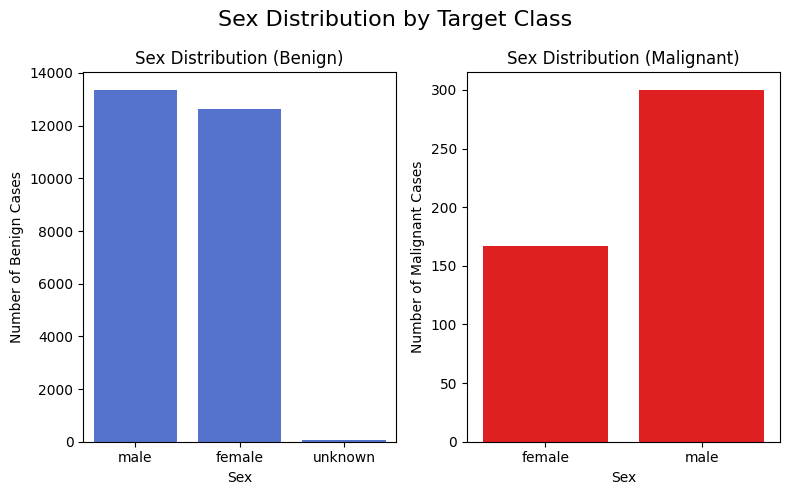

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.countplot(
    data=unencoded_train_df[unencoded_train_df["target"] == 0],
    x="sex",
    color="royalblue",
    ax=axes[0]
)
axes[0].set_title("Sex Distribution (Benign)")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Number of Benign Cases")

sns.countplot(
    data=unencoded_train_df[unencoded_train_df["target"] == 1],
    x="sex",
    color="red",
    ax=axes[1]
)
axes[1].set_title("Sex Distribution (Malignant)")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Number of Malignant Cases")

fig.suptitle("Sex Distribution by Target Class", fontsize=16)

plt.tight_layout()
plt.show()

Even though the number of benign samples is nearly the same for men and women, this balance does not hold for malignant cases. <u>Men make up a much larger share of the malignant population compared to women.</u> We now examine the overall sex distribution to check whether this difference may be explained by a sampling bias:

/tmp/ipython-input-2551515797.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=unencoded_train_df, x="sex", palette={"male": "royalblue", "female": "red", "unknown": "#222222"}, legend=True)


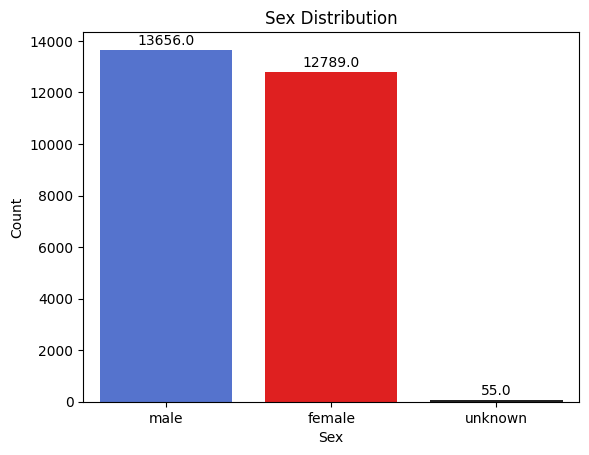

In [21]:
ax = sns.countplot(data=unencoded_train_df, x="sex", palette={"male": "royalblue", "female": "red", "unknown": "#222222"}, legend=True)

ax.set_title("Sex Distribution")
ax.set_xlabel("Sex")
ax.set_ylabel("Count")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height}",
                (p.get_x() + p.get_width() / 2., height + 80),
                ha="center", va="bottom")

plt.show()

Finally, we can rest assured that both genders are **represented almost equally** in the training population, which confirms that the overrepresentation of men in the malignant group is **not the result of a sampling bias.** Consequently, we conclude that there is a <u>strong correlation between being male and being diagnosed as malignant.</u> We now investigate this further by assessing the malignant cases count distribution of men by age:

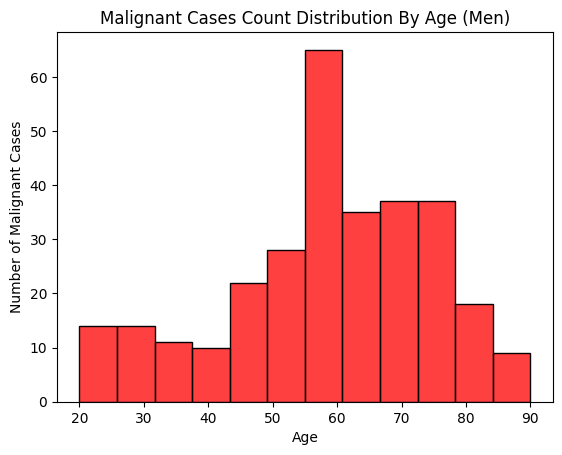

In [22]:
malignant_men_samples = unencoded_train_df[(unencoded_train_df["target"] == 1) & (unencoded_train_df["sex"] == "male")]
ax = sns.histplot(data=malignant_men_samples, x="age_approx", color="red")

ax.set_xlabel("Age")
ax.set_ylabel("Number of Malignant Cases")
ax.set_title("Malignant Cases Count Distribution By Age (Men)")

plt.show()

It is clear from the histogram above that men in the age range of roughly 50-80 are strongly represented among malignant cases compared to those in the 20-45 range. To make this more explicit, we now count the number of malignant male samples within consecutive 20-year intervals of `age`:

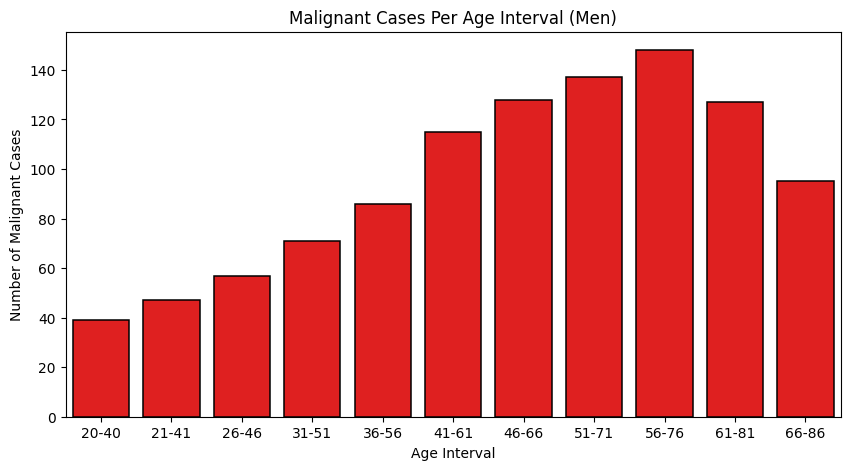

In [23]:

def get_interval_counts(df, column, interval_length):
  rows = []
  last_interval_count = -1

  min_val, max_val = df[column].min(), df[column].max()

  for interval_start in range(int(min_val), int(max_val - interval_length) + 1):
    interval_end = interval_start + interval_length
    interval_count = ((df[column] >= interval_start) & (df[column] < interval_end)).sum()

    if interval_count != last_interval_count:
      rows.append({"start": interval_start, "end": interval_end, "count": interval_count, "label": f"{interval_start}-{interval_end}"})
      last_interval_count = interval_count

  new_df = pandas.DataFrame(rows)
  return new_df

age_interval_count_df = get_interval_counts(malignant_men_samples, "age_approx", 20)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=age_interval_count_df, x="label", y="count", color="red", edgecolor="black", linewidth=1.1)

ax.set_xlabel("Age Interval")
ax.set_ylabel("Number of Malignant Cases")
ax.set_title("Malignant Cases Per Age Interval (Men)")

plt.show()

Certain age intervals in the histogram contain **two to three times** more malignant male samples than others, suggesting a strong **relationship between older men and malignant cases.** Next, we examine whether a similar pattern holds for women as well:

/tmp/ipython-input-1827215049.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = malignant.pivot_table(


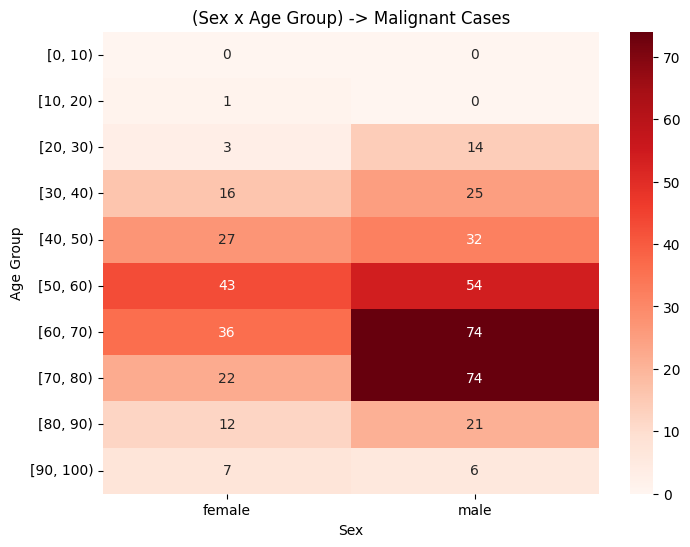

In [24]:
malignant = unencoded_train_df[unencoded_train_df["target"] == 1].copy()

bins = range(0, 101, 10)
malignant["age_bin"] = pandas.cut(malignant["age_approx"], bins=bins, right=False)

pivot = malignant.pivot_table(
    index="age_bin",
    columns="sex",
    values="target",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds")
plt.title("(Sex x Age Group) -> Malignant Cases")
plt.xlabel("Sex")
plt.ylabel("Age Group")
plt.show()

As we can see, the distribution of malignant cases among women is slightly more concentrated in the lower age intervals compared to men.

**Target Distribution By Anatomical Site**

!!!(add here)

**Diagnosis Correlation With Target**

!!!(verify here that diagnosis is strongly correlated with target)

## **Feature Extraction**

**Loading The Images**

Let's start by creating a `tf.data.Dataset` object from the image paths

In [25]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 64

In [26]:
train_image_paths_dataset = tf.data.Dataset.from_tensor_slices(train_df["image_path"])
val_image_paths_dataset = tf.data.Dataset.from_tensor_slices(val_df["image_path"])
test_image_paths_dataset = tf.data.Dataset.from_tensor_slices(test_df["image_path"])

We extract a stable image_id from the path so we can merge embeddings back to `train_df` later:

In [27]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def path_to_image_id(path):
    filename = tf.strings.split(path, '/')[-1]
    image_id = tf.strings.regex_replace(filename, r"\.(jpg|jpeg|png)$", "")
    return image_id

def decode_and_preprocess(path):
    path = tf.cast(path, tf.string)
    bytestr = tf.io.read_file(path)
    img = tf.image.decode_image(bytestr, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, path_to_image_id(path)

Now we build the image `Dataset` objects from the processing pipeline:

In [28]:
def build_image_dataset(ds_files, batch_size=BATCH_SIZE):
    ds = ds_files.map(decode_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [29]:
train_images_dataset = build_image_dataset(train_image_paths_dataset, BATCH_SIZE)
val_images_dataset = build_image_dataset(val_image_paths_dataset, BATCH_SIZE)
test_images_dataset = build_image_dataset(test_image_paths_dataset, BATCH_SIZE)

**Display Malignant & Benign Images**

In [30]:
import matplotlib.image as mpimg

def show_samples(df, title, ncols=5):
  fig, axes = plt.subplots(2, ncols, figsize=(15, 6))
  fig.suptitle(title, fontsize=14)
  axes = axes.flatten()

  for i, (_, row) in enumerate(df.iterrows()):
      if i >= len(axes): # Stop if we run out of axes
          break
      img_path = os.path.join(train_images_path, f"{row['image_name']}.jpg")
      img = mpimg.imread(img_path)
      axes[i].imshow(img)
      axes[i].axis("off")

  for j in range(i + 1, len(axes)):
      axes[j].axis("off")

  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

Images of 10 random benign skin moles (after resizing)

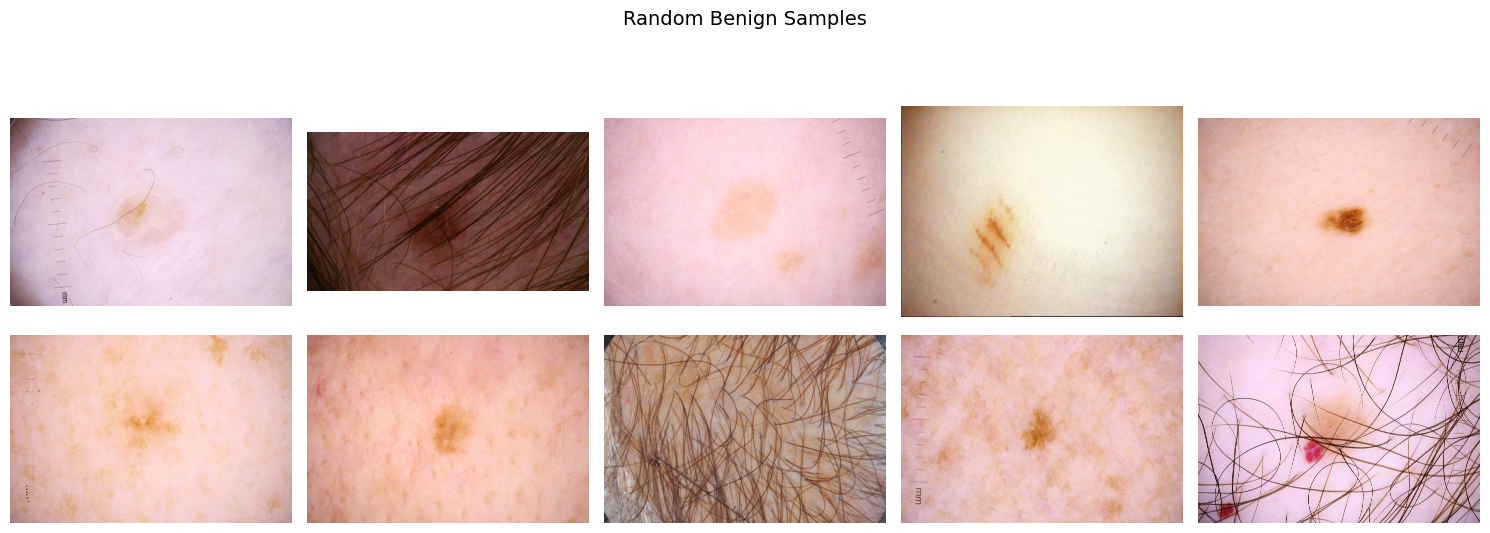

In [31]:
random_benign_samples = train_df[train_df["target"] == 0].sample(10, random_state=42)
show_samples(random_benign_samples, "Random Benign Samples")

Images of 10 random maligant skin moles

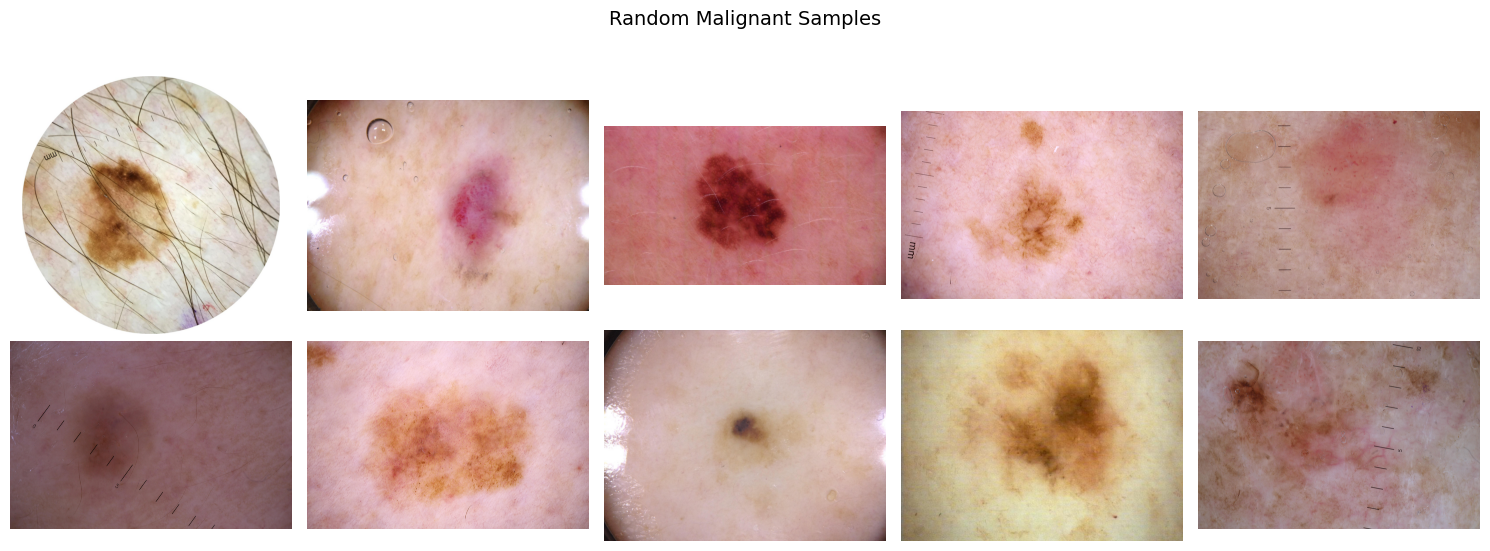

In [32]:
random_malignant_samples = train_df[train_df["target"] == 1].sample(10, random_state=42)
show_samples(random_malignant_samples, "Random Malignant Samples")

**Manual Feature Engineering**

One approach to feature extraction is to manually propose a feature whose value varies across the different classes. For example, if we find that `malignant` samples are typically noisier than `benign` ones, we can explicitly incorporate noise **as a feature** during training. This could help the model generalize better to unseen data - but the question of how to evaluate unseen data that lacks this feature explicitly remains. Evaluating a test sample will first require extracting the feature from the sample, and then using the enhanced model to predict its value.

!!!

**Automatic Feature Extraction**

We prefer a manual loop so we can collect embeddings and IDs together (Keras predict only returns outputs).

In [33]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tqdm.notebook import tqdm

def get_embeddings(model, last_layer_index, batches=10):
  model = Model(inputs=model.inputs, outputs=model.layers[last_layer_index].output)

  train_embeddings = []
  train_ids = []

  batch_iterator = iter(train_images_dataset)

  for _ in tqdm(range(batches), desc="Calculating Embeddings:"):
    batch_imgs, batch_ids = next(batch_iterator)

    batch_embeddings = model(batch_imgs, training=False)
    train_embeddings.append(batch_embeddings.numpy())
    train_ids.extend(batch_ids.numpy().astype(str))

  return (train_ids, train_embeddings)

In [34]:
base = EfficientNetB0(weights="imagenet", include_top=True, pooling="avg")
model = Model(inputs=base.input, outputs=base.output)

train_ids, train_embeddings = get_embeddings(base, -2, batches=5)
# Stack the batches of embeddings to a single 2D tensor.
train_embeddings = numpy.vstack(train_embeddings)

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Calculating Embeddings::   0%|          | 0/5 [00:00<?, ?it/s]

**Dimensionality Reduction - PCA**

Dimensionality Reduction is a powerful technique that is often used to remove features of the feature vector that are considered less important. One common algorithm for Dimensionality Reduction is Principle Component Analysis (PCA). This algorithm projects the data onto a k-dimensional vector-space that preserves the most amount of total variance of all other vector-spaces of the same dimensionality. The following utility class reduces the data samples using the `reduce` method and trains a logistic-regression classifier on the low-dimensional samples. The `reduce_train` method does one after the other.

In [35]:
def pca_reduce(X, n_dims):
  '''
  Returned a low dimensional representation of the data
  of 'n_dim' dimensions that is found by the PCA algorithm.
  '''
  X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
  X_centered = X_tensor - tf.reduce_mean(X_tensor, axis=0, keepdims=True)

  # TF returns S,U,V such that Xc = U diag(S) V^T
  singular_values_vector, U, V = tf.linalg.svd(X_centered, compute_uv=True, full_matrices=False)
  components = tf.transpose(V[:, :n_dims])

  Z = tf.matmul(X_centered, tf.transpose(components))
  n_minus_1 = tf.cast(tf.shape(X_centered)[0] - 1, tf.float32)
  total_var = tf.reduce_sum(singular_values_vector**2) / n_minus_1
  low_var = tf.reduce_sum((singular_values_vector[:n_dims])**2) / n_minus_1

  return {"data": Z,
          "low-dim-variance": low_var,
          "high-dim-variance": total_var,
          "principal-components": components}

We first examine the low-dimensional representation of the data by different features. Let's reduce the data to 2D and plot it on the 2D-plane using `blue` and `red` colors to differentiate between benign and malignant samples, correspondigly.

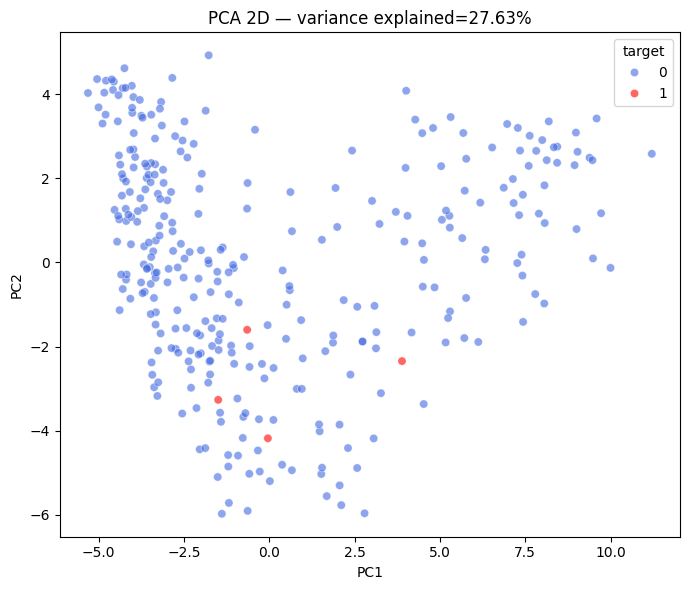

In [37]:
result = pca_reduce(train_embeddings, n_dims=2)
Z = result["data"].numpy()

filtered_train_df = train_df[train_df['image_name'].isin(train_ids)].copy()

# Build dataframe with target for coloring
df = pandas.DataFrame({
    "PC1": Z[:,0],
    "PC2": Z[:,1],
    "target": filtered_train_df["target"].values
})

plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="target",
                palette={0:"royalblue", 1:"red"}, alpha=0.6)
plt.title(f"PCA 2D — variance explained={result['low-dim-variance'].numpy()/result['high-dim-variance'].numpy():.2%}")
plt.tight_layout()
plt.show()

**Dimensionality Reduction - t-SNE**

!!!

**Visualizing Image Embeddings**

**Low-Dimensional Visualization of the Complete Dataset**

!!! Reduce the encoded vectors of the training set to 2D using PCA (without the target variable) - and color the low-dim vectors based on their target variable value.

## **Dimensionality Reduction & Clustering**

## **Conclusion**

# **Supervised Learning**

!!!
1. Track the validation & training error during the training process using ModelCheckpoint + history = model.fit(), history.history.
2. make sure that the model stops it's training after X num of epochs and save the current number of epochs that were successfully finalized after each epoch's ending.
3. Save the models with different name for each model in a folder /model specifically allocated for them. Inside /model/epoch save the number of epochs each model completed successfully.

Machine Learning Algorithm (Logistic Regression)

Machine Learning Algorithm (Logistic Regression with Regularization & Cross Validation (for choosing the best regularization strength))

Deep Learning Algorithm (with vectors only)

Deep Learning Algorithm (EfficientNet)

Deep Learning Algorithm (EfficientNet + Augmentation Layer)

Deep Learning Algorithm (EfficientNet with Regularization & Cross Validation + Augmentation)